# Gemma 2 SAE steering: capability cost on an MMLU subset

**Question:** How much does additive SAE-feature steering change Gemma 2 2B's
multiple-choice accuracy as steering strength increases?

**Answer/status:** Gemma results have **not been measured in this notebook yet**.
The saved offline example below demonstrates the paired analysis only. Set
`RUN_GEMMA = True`, run all cells on a GPU, and save the executed notebook to obtain
real accuracy tables and plots. No GPU was available during notebook development.

We use **`google/gemma-2-2b` (base)** and its matching **Gemma Scope residual SAE**,
layer 20, width 16,384, average L0 71. This is deliberately a different model from
`pretrained_generated_answer_summary.ipynb`'s Gemma 4 31B default. A Gemma 4 lens
or a different model's SAE cannot be reused here.

The default experiment is a reproducible **zero-shot, 256-question MMLU pilot**:
32 test questions from each of eight fixed subjects, evaluated unchanged under every
condition. It is not a full MMLU benchmark or a generated-answer evaluation.

## Setup

Run from this checkout with `uv sync --extra dev`, then select its Python kernel.
On Colab, the setup cell clones this fork if needed and installs it. Authenticate
with Hugging Face separately (for example, `huggingface_hub.login()` without a
literal token in the notebook) and accept the Gemma model license before loading.
No credentials are stored in this notebook. A CUDA GPU is recommended; weights alone
are about 5.2 GB in bf16, with additional memory for activations and readout.
Use a persistent `CACHE_DIR` to retain results between Colab runtimes.

No SAE Lens dependency is needed: additive feature steering only needs selected
`W_dec` rows from the official NPZ archive. We never fit a lens or an SAE.

In [1]:
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/t-ravnushkin/j-lens-steering.git"
INSTALL_DEPENDENCIES = "COLAB_RELEASE_TAG" in os.environ or "google.colab" in sys.modules
REPO_DIR = next(
    (p for p in [Path.cwd(), *Path.cwd().parents]
     if (p / "jlens" / "evaluation.py").is_file()), None,
)
if REPO_DIR is None:
    REPO_DIR = Path.cwd() / "jacobian-lens-gpt2"
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
REPO_DIR = REPO_DIR.resolve()
if INSTALL_DEPENDENCIES:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(REPO_DIR)], check=True)
sys.path.insert(0, str(REPO_DIR))
if not (REPO_DIR / "jlens" / "sae_steering.py").is_file():
    raise RuntimeError("Use the checkout containing jlens/sae_steering.py and this notebook.")

In [2]:
import gc
import hashlib
import importlib.metadata
import json
import tempfile
from dataclasses import asdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from huggingface_hub import hf_hub_download
from IPython.display import display
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

from jlens import from_hf
from jlens.sae_steering import (
    SteeringCondition,
    encode_choice_prompts,
    evaluate_choice_steering,
    load_gemma_scope_directions,
    summarize_capability,
)

RUN_GEMMA = False  # Set True for the real experiment, then Run All and save outputs.
CACHE_DIR = REPO_DIR / "runs" / "gemma_sae_mmlu"  # Git-ignored; use mounted storage on Colab.
CFG = {
    "model_id": "google/gemma-2-2b",
    "model_revision": "c5ebcd40d208330abc697524c919956e692655cf",
    "sae_repo": "google/gemma-scope-2b-pt-res",
    "sae_revision": "fd571b47c1c64851e9b1989792367b9babb4af63",
    "sae_file": "layer_20/width_16k/average_l0_71/params.npz",
    "layer": 20,
    "feature_ids": [4628],  # Example feature; choose features before inspecting MMLU results.
    "strengths": [0.0, 0.025, 0.05, 0.1, 0.2],  # Signed values also supported.
    "random_seeds": [11, 22, 33],
    "positions": "all",  # All real prompt tokens except BOS; alternatively "last".
    "dataset_id": "cais/mmlu",
    "dataset_revision": "c30699e8356da336a370243923dbaf21066bb9fe",
    "subjects": [
        "abstract_algebra", "computer_security", "high_school_biology",
        "high_school_physics", "high_school_world_history", "philosophy",
        "high_school_psychology", "professional_medicine",
    ],
    "per_subject": 32,
    "sample_seed": 2026,
    "batch_size": 8,  # Total prompt-condition rows, not prompts per setting.
    "max_batch_tokens": 4096,
    "max_seq_len": 2048,  # Overlength questions raise; never silently truncated/dropped.
    "cache_chunk_items": 16,
    "device": "cuda",
    "dtype": "bfloat16",  # Set float16 on GPUs without bf16 support; float32 for CPU.
}
BOOTSTRAP_SAMPLES = 2000
BOOTSTRAP_SEED = 2026

## Method and relationship to J-space steering

The existing J-space intervention code is in
[`jlens/workspace.py`](../../jlens/workspace.py): `lens_direction`, `InjectDirection`
and `ClampSwap`. Those directions come from a fitted Jacobian lens and vocabulary
readout. Here the direction is the SAE decoder row for feature $f$:

$$h'_{b,t}=h_{b,t}+\alpha\,\|h_{b,t}\|_2\frac{W_{\mathrm{dec}}[f]}{\|W_{\mathrm{dec}}[f]\|_2}.$$

We hook the **output of zero-based block 20** (`resid_post`), where this SAE was
trained. Each token uses its own clean residual norm, which is identical across
conditions before this single-layer intervention. Thus 0.1 means an update with
L2 norm 10% of that token's residual norm, before dtype rounding. This differs from
the existing J-space helper's band/mean-norm scaling; its numeric strengths are not
interchangeable. Negative strength reverses the direction; it is not latent ablation.
We do not reconstruct activations or remove reconstruction error.

Conditions are an unsteered baseline (zero update), each selected SAE feature at
all strengths, and three fixed Gaussian unit directions at each nonzero strength.
The random directions have the same update norm at every token. Zero-strength SAE
rows must match the baseline. Prompts and conditions are expanded into one work list,
length-sorted and batched together. Right padding is masked; BOS and padding are
never steered. Readout uses the last real token and the model's native normalization,
LM head and logit softcap. Offline regression tests also compare the zero hook against
an entirely unhooked native Gemma forward pass.

**Feature selection:** 4628 is an illustrative preselected feature with
[automated Bitcoin-related annotations](https://www.neuronpedia.org/gemma-2-2b/20-gemmascope-res-16k/4628).
These annotations are hypotheses, not a verified semantic control. Edit `feature_ids`
using this exact SAE's feature browser, then freeze the choice before evaluation.
Accuracy loss alone does not demonstrate successful semantic steering. A semantic
control study should separately validate the desired behavior on independent prompts.

**Scoring:** zero-shot plain completion, explicit BOS, no chat template or chain of
thought. Choose the highest-probability continuation among ` A`, ` B`, ` C`, ` D`.
The tokenizer must encode each as exactly one context-stable token; otherwise fail.
We also retain full-vocabulary label probabilities, correct-label NLL, conditional
four-choice NLL, and total answer-label mass to expose formatting/probability collapse.

**Analysis:** positive `loss_pp = 100 × (baseline accuracy − steered accuracy)` means
capability degradation. Paired item bootstrap resamples within the eight fixed subjects
and reports pointwise 95% intervals, not a multiple-testing-corrected significance test.
There is no feature/strength selection based on this test subset. Subject balance makes
the pooled mean equal to the mean of subject accuracies. Do not generalize these intervals
to all MMLU subjects or interpret an interval spanning zero as proof of no damage.

## Offline analysis example — synthetic, not Gemma results

Four invented questions: the baseline gets three right; steering loses two correct
answers and fixes one wrong answer. Accuracy goes from 75% to 50%, a **25 percentage
point loss**. This verifies paired accounting and probability summaries without weights.

,condition,n,accuracy,loss_pp,correct_to_wrong,wrong_to_correct
0,baseline,4,0.75,0.0,0,0
3,example_steering,4,0.50,25.0,2,1


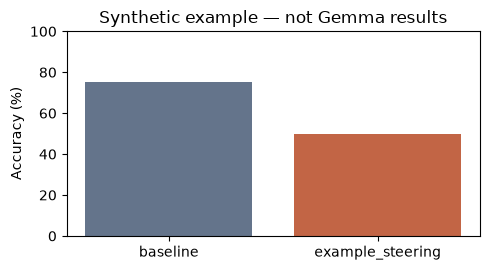

In [3]:
demo_items = pd.DataFrame({
    "item": [0, 1, 2, 3], "subject": ["synthetic_a", "synthetic_a", "synthetic_b", "synthetic_b"],
    "answer": [0, 1, 2, 3],
})
demo_rows = []
for name, predictions in [("baseline", [0, 1, 0, 3]), ("example_steering", [1, 1, 2, 0])]:
    for item, predicted in enumerate(predictions):
        probabilities = np.full(4, 0.05)
        probabilities[predicted] = 0.5
        demo_rows.append({"item": item, "condition": name,
                          **dict(zip([f"logp_{c}" for c in "ABCD"], np.log(probabilities), strict=True))})
demo_summary, _ = summarize_capability(pd.DataFrame(demo_rows), demo_items, seed=0)
demo_overall = demo_summary.query("subject == 'ALL'")
assert demo_overall.set_index("condition").loc["example_steering", "loss_pp"] == 25
display(demo_overall[["condition", "n", "accuracy", "loss_pp", "correct_to_wrong", "wrong_to_correct"]])
fig, ax = plt.subplots(figsize=(5, 2.8))
ax.bar(demo_overall.condition, 100 * demo_overall.accuracy, color=["#64748b", "#c26545"])
ax.set(ylabel="Accuracy (%)", ylim=(0, 100), title="Synthetic example — not Gemma results")
fig.tight_layout()
plt.show()
plt.close(fig)

## Prepare immutable inputs and cache identity

The three Hugging Face revisions above are pinned commits. Caches contain the selected
source row indices, question text, token IDs, answer IDs, direction hashes, exact settings,
software versions and implementation hashes. We use JSON, not pickle. Each completed
chunk is saved atomically, so interrupted runs resume completed model passes. Changing
settings creates a different cache directory; changing plot/bootstrap settings does not
require inference. Reuse a completed run with `RUN_GEMMA=True`; the model is not loaded
when every score chunk exists. To regenerate a run, move its result files aside first.

The SAE's original fitting corpus is external to this repo; no independence from MMLU
is asserted. This experiment performs no fitting (dimension batch size: not applicable).
Prompt length is recorded; batching budgets and compute dtype are in the manifest.

In [4]:
def fingerprint(value):
    return hashlib.sha256(json.dumps(value, sort_keys=True, allow_nan=False).encode()).hexdigest()


def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1 << 20), b""):
            digest.update(chunk)
    return digest.hexdigest()


def atomic_json(path, value):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with tempfile.NamedTemporaryFile("w", dir=path.parent, delete=False) as handle:
        temporary = Path(handle.name)
        json.dump(value, handle, sort_keys=True, allow_nan=False)
    temporary.replace(path)


def format_question(row):
    subject = row["subject"].replace("_", " ")
    options = "\n".join(f"{letter}. {choice}" for letter, choice in zip("ABCD", row["choices"], strict=True))
    return (f"The following is a multiple choice question about {subject}.\n\n"
            f"{row['question']}\n{options}\nAnswer:")


prepared_config = manifest = run_dir = items = sequences = choice_ids = None
conditions = direction_bank = tokenizer = scores = summary = details = None
if not RUN_GEMMA:
    print("Gemma preparation skipped: set RUN_GEMMA=True and Run All for measured results.")
else:
    prepared_config = fingerprint(CFG)
    if CFG["model_id"] != "google/gemma-2-2b" or CFG["sae_repo"] != "google/gemma-scope-2b-pt-res":
        raise ValueError("This notebook pins a matched Gemma 2 2B / Gemma Scope pair.")
    if CFG["layer"] != 20 or CFG["sae_file"] != "layer_20/width_16k/average_l0_71/params.npz":
        raise ValueError("Change the documented SAE/site contract before using a different layer.")
    if any(len(CFG[k]) != 40 or any(c not in "0123456789abcdef" for c in CFG[k])
           for k in ("model_revision", "sae_revision", "dataset_revision")):
        raise ValueError("Pin model, SAE and dataset to immutable commit revisions.")
    if not CFG["subjects"] or len(set(CFG["subjects"])) != len(CFG["subjects"]) or CFG["per_subject"] < 1:
        raise ValueError("Use unique subjects and a positive sample count.")
    if len(set(CFG["strengths"])) != len(CFG["strengths"]) or 0.0 not in CFG["strengths"]:
        raise ValueError("Use unique strengths including the zero-strength control.")
    if CFG["cache_chunk_items"] < 1:
        raise ValueError("cache_chunk_items must be positive.")
    tokenizer = AutoTokenizer.from_pretrained(CFG["model_id"], revision=CFG["model_revision"])
    dataset = load_dataset(CFG["dataset_id"], "all", split="test", revision=CFG["dataset_revision"])
    selected = []
    for subject in CFG["subjects"]:
        indices = [i for i, value in enumerate(dataset["subject"]) if value == subject]
        if len(indices) < CFG["per_subject"]:
            raise ValueError(f"Not enough test questions in {subject}.")
        seed = int(fingerprint([CFG["sample_seed"], subject])[:16], 16)
        chosen = sorted(np.random.default_rng(seed).choice(indices, CFG["per_subject"], replace=False).tolist())
        for source_row in chosen:
            row = dataset[source_row]
            selected.append({"item": len(selected), "source_row": source_row, **row,
                             "prompt": format_question(row)})
    items = pd.DataFrame(selected)
    sequences, choice_ids = encode_choice_prompts(tokenizer, items.prompt.tolist(), max_seq_len=CFG["max_seq_len"])
    sae_path = hf_hub_download(CFG["sae_repo"], CFG["sae_file"], revision=CFG["sae_revision"])
    sae_directions = load_gemma_scope_directions(sae_path, CFG["feature_ids"], d_model=2304)
    direction_parts = [sae_directions]
    conditions = [SteeringCondition("baseline", 0, 0.0)]
    condition_rows = [{"condition": "baseline", "kind": "baseline", "feature": "baseline", "strength": 0.0}]
    for index, feature in enumerate(CFG["feature_ids"]):
        for strength in CFG["strengths"]:
            name = f"sae_{feature}@{strength:g}"
            conditions.append(SteeringCondition(name, index, strength))
            condition_rows.append({"condition": name, "kind": "sae", "feature": str(feature), "strength": strength})
    for index, seed in enumerate(CFG["random_seeds"]):
        vector = torch.randn(1, 2304, generator=torch.Generator().manual_seed(seed))
        direction_parts.append(vector / vector.norm(dim=-1, keepdim=True))
        for strength in CFG["strengths"]:
            if strength == 0:
                continue
            name = f"random_{seed}@{strength:g}"
            conditions.append(SteeringCondition(name, len(sae_directions) + index, strength))
            condition_rows.append({"condition": name, "kind": "random", "feature": str(seed), "strength": strength})
    direction_bank = torch.cat(direction_parts)
    condition_table = pd.DataFrame(condition_rows)
    implementation_files = [REPO_DIR / "jlens" / name for name in ("sae_steering.py", "hf.py", "hooks.py")]
    manifest = {
        "protocol": "gemma-sae-mmlu-v1-zero-shot-label-continuations",
        "config": json.loads(json.dumps(CFG)),
        "items": selected, "sequences": sequences, "choice_ids": choice_ids,
        "conditions": [asdict(c) for c in conditions],
        "sae_sha256": file_sha256(sae_path),
        "direction_sha256": hashlib.sha256(direction_bank.numpy().tobytes()).hexdigest(),
        "tokenizer_sha256": hashlib.sha256(tokenizer.backend_tokenizer.to_str().encode()).hexdigest(),
        "implementation": {p.name: file_sha256(p) for p in implementation_files},
        "versions": {name: importlib.metadata.version(name) for name in
                     ("torch", "transformers", "numpy", "datasets", "huggingface_hub")},
        "precision": {"matmul": torch.get_float32_matmul_precision(),
                      "tf32": torch.backends.cuda.matmul.allow_tf32},
        "fitting": "none; external SAE training provenance: Google Gemma Scope",
    }
    run_id = fingerprint(manifest)
    run_dir = Path(CACHE_DIR).expanduser().resolve() / run_id
    atomic_json(run_dir / "manifest.json", manifest)
    atomic_json(run_dir / "conditions.json", condition_rows)
    print(f"Run: {run_id}\nCache: {run_dir}")
    print(f"{len(items)} questions × {len(conditions)} conditions = {len(items) * len(conditions)} rows")
    display(items.groupby("subject").size().rename("questions").to_frame())
    display(pd.Series([len(s) for s in sequences], name="prompt_tokens").describe().to_frame())
    display(condition_table)

Gemma preparation skipped: set RUN_GEMMA=True and Run All for measured results.


## Evaluate and resume cached chunks

Start with smaller `per_subject`/`strengths` for a quick smoke run. Reduce
`batch_size` and `max_batch_tokens` if GPU memory is tight. This is one-device inference;
there is no automatic device sharding or quantization. Keep the same batching settings
for a comparison. Each cache chunk contains all conditions on the same questions.

Model loading happens only after missing chunks are identified. The first uncached chunk
also checks Gemma's loaded width/layer count against the SAE. Exceptions remove steering
hooks; completed chunks remain available. Full-vocabulary logits are computed only at
the final real token, avoiding a `[batch, sequence, vocabulary]` allocation.

In [5]:
def require_prepared():
    if prepared_config is None or prepared_config != fingerprint(CFG):
        raise RuntimeError("Configuration changed or is missing; rerun preparation before evaluation.")
    if any(file_sha256(REPO_DIR / "jlens" / name) != digest
           for name, digest in manifest["implementation"].items()):
        raise RuntimeError("Implementation changed; restart the kernel and Run All.")


scores = summary = details = None
# Release references from a previous execution before loading another model.
for name in ("adapter", "hf_model"):
    globals().pop(name, None)
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
if not RUN_GEMMA:
    print("Model inference skipped; no Gemma performance numbers are available.")
else:
    require_prepared()
    chunks = [(start, min(start + CFG["cache_chunk_items"], len(items)))
              for start in range(0, len(items), CFG["cache_chunk_items"])]
    missing = [(start, end) for start, end in chunks if not (run_dir / f"scores-{start}-{end}.json").exists()]
    if missing:
        if CFG["device"].startswith("cuda") and not torch.cuda.is_available():
            raise RuntimeError("No CUDA GPU found. Use a GPU runtime or explicitly configure CPU/float32.")
        if CFG["device"].startswith("cuda") and CFG["dtype"] == "bfloat16" and not torch.cuda.is_bf16_supported():
            raise RuntimeError("This GPU does not support bf16; configure float16 and rerun preparation.")
        hf_model = AutoModelForCausalLM.from_pretrained(
            CFG["model_id"], revision=CFG["model_revision"], dtype=getattr(torch, CFG["dtype"]),
            attn_implementation="eager",
        ).to(CFG["device"]).eval()
        adapter = from_hf(hf_model, tokenizer, compile=False, force_bos=False)
        if adapter.d_model != direction_bank.shape[1] or adapter.n_layers != 26:
            raise ValueError("Loaded model does not match the Gemma Scope SAE contract.")
        direction_bank_device = direction_bank.to(adapter.input_device)
        for start, end in tqdm(missing, desc="Uncached MMLU chunks"):
            chunk_scores = evaluate_choice_steering(
                adapter, sequences[start:end], choice_ids, direction_bank_device, conditions,
                layer=CFG["layer"], pad_token_id=tokenizer.pad_token_id,
                batch_size=CFG["batch_size"], max_batch_tokens=CFG["max_batch_tokens"],
                positions=CFG["positions"],
            )
            chunk_scores["item"] += start
            atomic_json(run_dir / f"scores-{start}-{end}.json",
                        {"run_id": run_id, "start": start, "end": end,
                         "records": chunk_scores.to_dict(orient="records")})
        del adapter, hf_model, direction_bank_device
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    else:
        print("All inference chunks are cached; model weights were not loaded.")
    score_parts = []
    for start, end in chunks:
        payload = json.loads((run_dir / f"scores-{start}-{end}.json").read_text())
        if (payload["run_id"], payload["start"], payload["end"]) != (run_id, start, end):
            raise ValueError("Cache provenance mismatch.")
        part = pd.DataFrame(payload["records"])
        expected = {(i, c.name) for i in range(start, end) for c in conditions}
        if len(part) != len(expected) or set(zip(part.item, part.condition, strict=True)) != expected:
            raise ValueError("Incomplete/duplicate cache rows; move the invalid chunk aside and rerun.")
        score_parts.append(part)
    scores = pd.concat(score_parts, ignore_index=True)
    baseline = scores[scores.condition.eq("baseline")].set_index("item").sort_index()
    for condition in conditions:
        if condition.strength == 0:
            zero = scores[scores.condition.eq(condition.name)].set_index("item").sort_index()
            np.testing.assert_allclose(zero[[f"logp_{c}" for c in "ABCD"]],
                                       baseline[[f"logp_{c}" for c in "ABCD"]], atol=2e-3, rtol=0)
    print(f"Loaded {len(scores)} scored rows; zero-strength controls agree within dtype tolerance.")

Model inference skipped; no Gemma performance numbers are available.


## Results: paired capability loss and strength curves

The tables and plots below are populated only from actual model scores. Positive
loss means worse accuracy than baseline. Error bars are paired, subject-stratified
bootstrap intervals. Random seeds are separate controls, not extra question samples.
The shaded random range is descriptive variation across three fixed directions,
not an uncertainty interval. Inspect each seed in the table.

Correct-label NLL uses full-vocabulary probability; conditional NLL renormalizes over
the four answer letters. Low answer-label mass means the forced-choice score can hide
an output-format change. Neither metric is a generated-answer score.

In [6]:
if RUN_GEMMA:
    require_prepared()
    if scores is None:
        raise RuntimeError("Run the evaluation/cache cell first.")
    summary, details = summarize_capability(
        scores, items[["item", "subject", "answer"]],
        n_bootstrap=BOOTSTRAP_SAMPLES, seed=BOOTSTRAP_SEED,
    )
    summary = summary.merge(condition_table, on="condition", validate="many_to_one")
    overall = summary[summary.subject.eq("ALL")].copy()
    display(overall[["condition", "n", "accuracy", "loss_pp", "loss_ci_low_pp", "loss_ci_high_pp",
                     "correct_to_wrong", "wrong_to_correct", "prediction_flip_rate", "nll",
                     "conditional_nll", "answer_mass"]].round(4))
    display(summary[~summary.subject.eq("ALL")].pivot(index="subject", columns="condition", values="loss_pp").round(2))
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    base_accuracy = float(overall.loc[overall.kind.eq("baseline"), "accuracy"].iloc[0])
    for feature, group in overall[overall.kind.eq("sae")].groupby("feature"):
        group = group.sort_values("strength")
        axes[0].plot(group.strength, group.accuracy * 100, "o-", label=f"SAE {feature}")
        axes[1].plot(group.strength, group.loss_pp, "o-", label=f"SAE {feature}")
        # Draw endpoints directly: bootstrap percentile intervals need not center on the estimate.
        axes[1].vlines(group.strength, group.loss_ci_low_pp, group.loss_ci_high_pp, alpha=.5)
        axes[2].plot(group.strength, group.answer_mass, "o-", label=f"SAE {feature}")
    random = overall[overall.kind.eq("random")]
    for ax, metric, scale in [(axes[0], "accuracy", 100), (axes[1], "loss_pp", 1), (axes[2], "answer_mass", 1)]:
        if not random.empty:
            band = random.groupby("strength")[metric].agg(["min", "mean", "max"]).sort_index()
            ax.plot(band.index, band["mean"] * scale, "--", color="gray", label="Random mean")
            ax.fill_between(band.index, band["min"] * scale, band["max"] * scale, color="gray", alpha=.15)
        ax.set_xlabel("Signed residual-relative strength")
        ax.grid(alpha=.2)
        ax.legend(fontsize=8)
    axes[0].axhline(base_accuracy * 100, color="black", linestyle=":", label="Baseline")
    axes[0].axhline(25, color="gray", linestyle=":")
    axes[0].set(ylabel="MMLU subset accuracy (%)", ylim=(0, 100))
    axes[0].legend(fontsize=8)
    axes[1].axhline(0, color="black", linestyle=":")
    axes[1].set_ylabel("Accuracy loss vs baseline (pp)")
    axes[2].set(ylabel="Total probability of answer labels", ylim=(0, 1))
    fig.suptitle(f"Gemma 2 2B · SAE layer {CFG['layer']} · {len(items)} fixed MMLU items")
    fig.tight_layout()
    fig.savefig(run_dir / "capability.png", dpi=160)
    plt.show()
    plt.close(fig)
    summary.to_csv(run_dir / "summary.csv", index=False)
    details.to_csv(run_dir / "item_scores.csv", index=False)
    atomic_json(run_dir / "analysis.json", {"bootstrap_samples": BOOTSTRAP_SAMPLES, "bootstrap_seed": BOOTSTRAP_SEED})
else:
    print("No measured Gemma tables or curves: RUN_GEMMA=False.")

No measured Gemma tables or curves: RUN_GEMMA=False.


## Inspect changed answers

Inspect the raw question, forced-choice predictions, full-vocabulary top token and
probability mass for both conditions. This helps distinguish incorrect answers from
changes in the probability of emitting an answer letter. It does not establish a
semantic steering effect.

In [7]:
if RUN_GEMMA:
    require_prepared()
    changed = details[details.prediction.ne(details.baseline_prediction)].copy()
    changed["predicted_letter"] = changed.prediction.map(dict(enumerate("ABCD")))
    changed["baseline_letter"] = changed.baseline_prediction.map(dict(enumerate("ABCD")))
    changed["top_token"] = [tokenizer.decode([int(i)]) for i in changed.top_token_id]
    base_mass = details[details.condition.eq("baseline")].set_index("item").answer_mass
    base_top = details[details.condition.eq("baseline")].set_index("item").top_token_id
    changed["baseline_answer_mass"] = changed.item.map(base_mass)
    changed["baseline_top_token"] = [tokenizer.decode([int(i)]) for i in changed.item.map(base_top)]
    changed = changed.merge(items[["item", "question", "choices"]], on="item", validate="many_to_one")
    display(changed.groupby("condition", sort=False).head(3)[[
        "condition", "subject", "question", "choices", "answer", "baseline_letter",
        "predicted_letter", "baseline_top_token", "top_token", "baseline_answer_mass", "answer_mass",
    ]])

## Conclusions and limits

The offline example establishes the analysis contract, not Gemma performance. After
running the experiment, the cell below reports baseline accuracy and the range of
observed SAE losses. Use the full table and pointwise intervals; no setting is selected
as an optimum. Save the notebook so measured tables and plots travel with it.

A loss here is evidence of side effects under this particular prompt format, feature,
layer and position policy. It does not measure all capabilities or verify that the
intended concept was successfully steered. Small subject samples, low baseline accuracy,
forced-choice formatting and external training-data overlap limit conclusions. Three
random directions provide a modest norm-matched control, not a full random null study.
Use independent development prompts for feature/strength choices and a fresh held-out
sample for confirmatory evaluation.

Sources: [Google Gemma Scope model card](https://huggingface.co/google/gemma-scope/blob/main/README.md),
[Gemma Scope technical report](https://arxiv.org/abs/2408.05147),
[the exact SAE archive](https://huggingface.co/google/gemma-scope-2b-pt-res/tree/fd571b47c1c64851e9b1989792367b9babb4af63/layer_20/width_16k/average_l0_71),
and [CAIS MMLU dataset](https://huggingface.co/datasets/cais/mmlu).

In [8]:
if RUN_GEMMA:
    require_prepared()
    sae_results = overall[overall.kind.eq("sae") & overall.strength.ne(0)]
    print(f"Measured baseline: {base_accuracy:.1%} on {len(items)} fixed questions.")
    if not sae_results.empty:
        print(f"Across the prespecified nonzero SAE conditions, observed accuracy loss ranges "
              f"from {sae_results.loss_pp.min():.2f} to {sae_results.loss_pp.max():.2f} pp.")
    print("Read the paired intervals and random controls above; semantic steering success is unmeasured.")
    print(f"Provenance, per-item scores and plots: {run_dir}")
else:
    print("Status: offline example executed; Gemma capability degradation remains unmeasured.")

Status: offline example executed; Gemma capability degradation remains unmeasured.
